In [1]:
import os
# Put this at the VERY TOP before importing torch or matplotlib!
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [35]:
import torch 
file = r"C:\qtri\Self-learning\SEACrowd\gated-continual-cartridges\outputs\swapping_20260422_185334_local\per_token_slot_llama_toks512_init_vs_trained_A_into_B_per_question\per_slot_swap.pt"
data_dict = torch.load(file, map_location='cpu')

C:\Users\voqua\AppData\Local\Temp\ipykernel_27932\1707169391.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load(file, map_location='cpu')


In [9]:
data.keys()

dict_keys(['log_ppl_per_slot', 'R', 'base_nll', 'donor_nll', 'grid_per_q', 'base_per_q', 'donor_per_q', 'question_ids'])

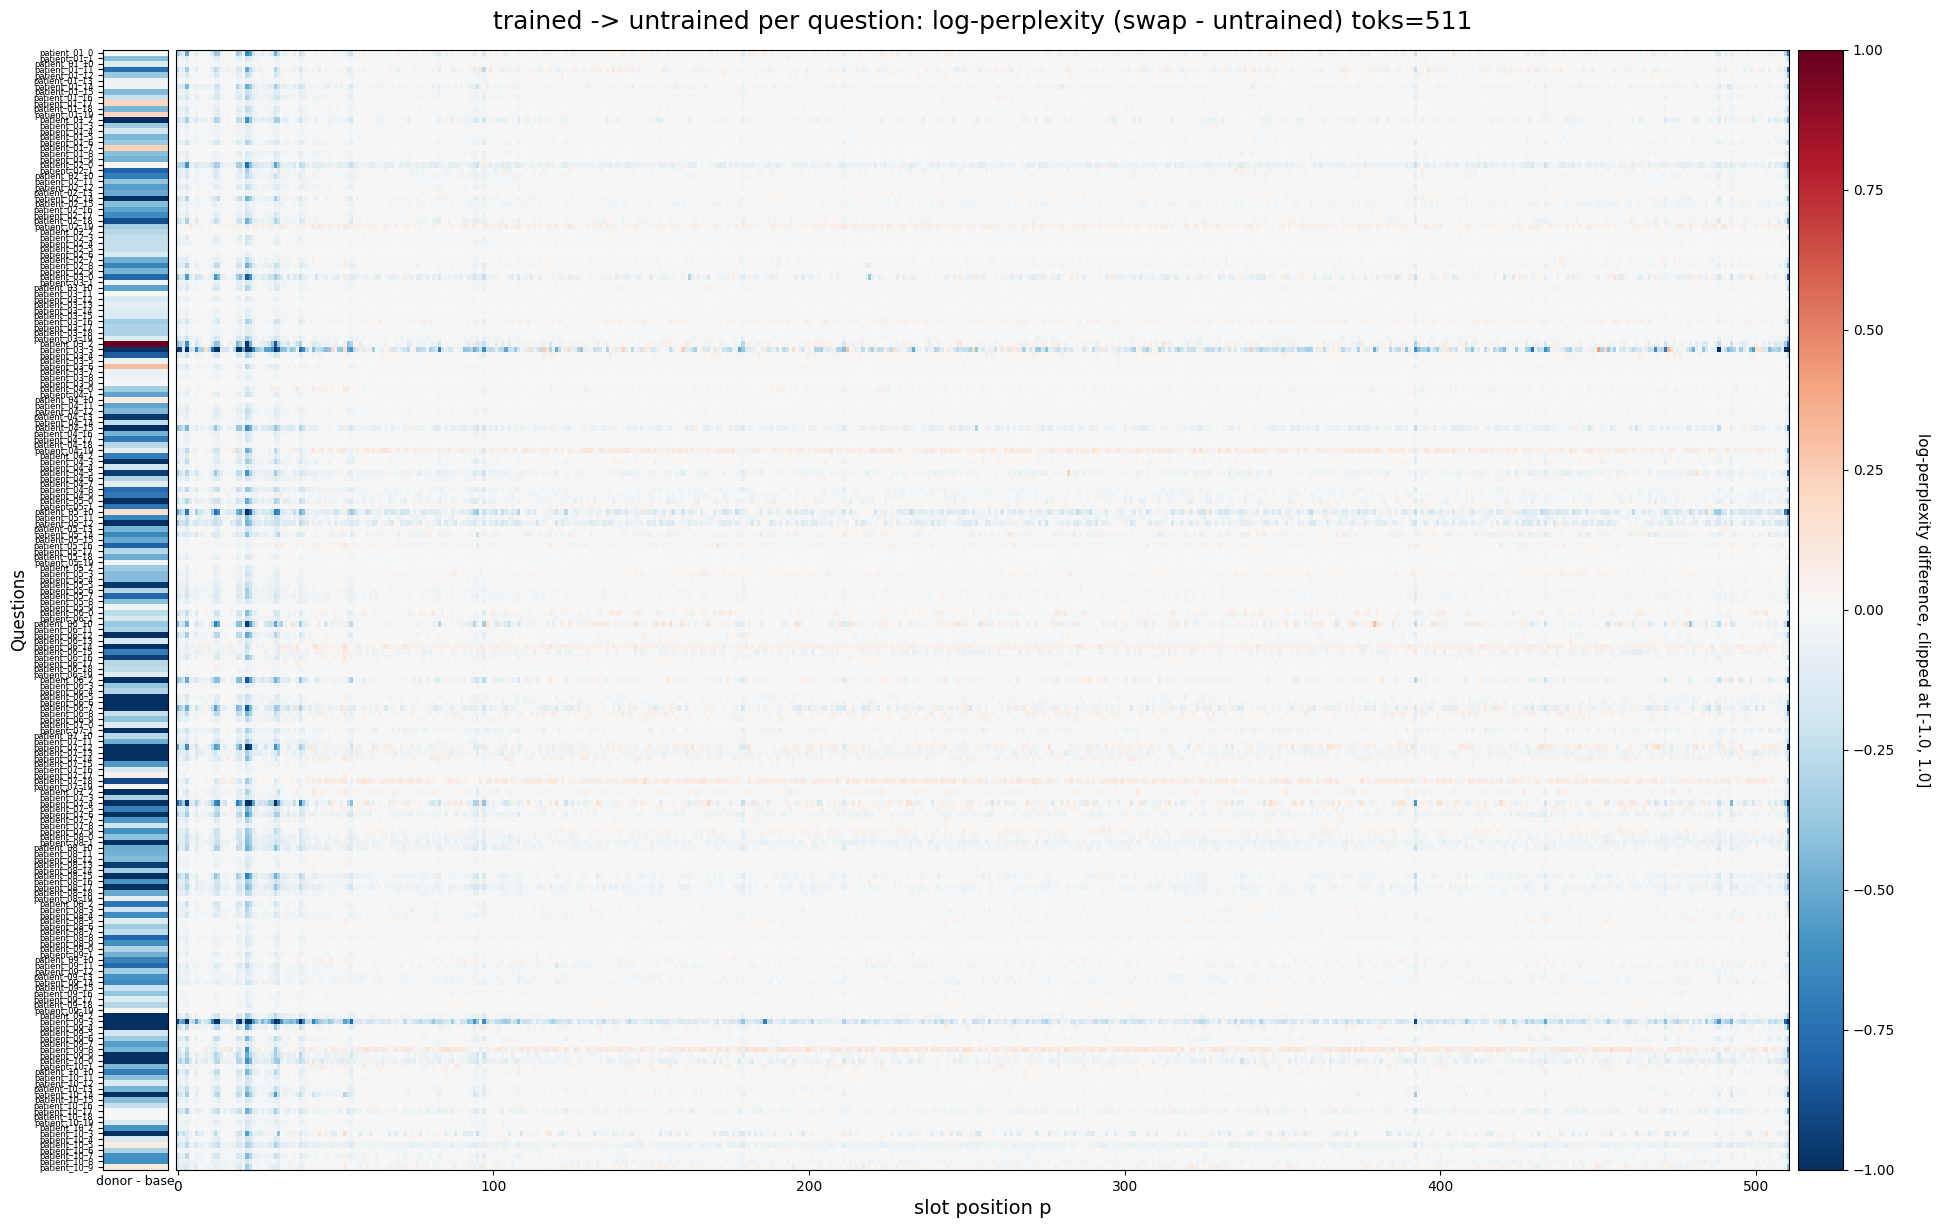

In [37]:
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
NUM_QUESTIONS, NUM_SLOTS = data_dict['grid_per_q'].shape

# --- STEP 2: SORT DATA BY QUESTION ID ---

# 1. Get the indices that would sort the question_ids list alphabetically
original_q_ids = data_dict['question_ids']
sorted_indices = sorted(range(len(original_q_ids)), key=lambda k: original_q_ids[k])

# 2. Sort the question_ids list
sorted_q_ids = [original_q_ids[i] for i in sorted_indices]

# 3. Convert indices to a tensor to reorder the PyTorch data tensors
idx_tensor = torch.tensor(sorted_indices)

sorted_grid_per_q = data_dict['grid_per_q'][idx_tensor]
sorted_base_per_q = data_dict['base_per_q'][idx_tensor]
sorted_donor_per_q = data_dict['donor_per_q'][idx_tensor]


# --- STEP 3: DATA PROCESSING ---

# 1. Main Grid Data: (sorted_grid) - (sorted_base broadcasted)
main_grid_data = sorted_grid_per_q - sorted_base_per_q.unsqueeze(1)

# 2. Left Column Data: (sorted_donor - sorted_base)
left_col_data = (sorted_donor_per_q - sorted_base_per_q).unsqueeze(1)

# 3. Fixed bounds from -1.0 to 1.0
VMIN = -1.0 
VMAX = 1.0 

# 4. Clip data to bounds and convert to NumPy for plotting
clipped_grid = torch.clamp(main_grid_data, VMIN, VMAX).numpy()
clipped_col = torch.clamp(left_col_data, VMIN, VMAX).numpy()


# --- STEP 4: HEATMAP PLOTTING WITH GRIDSPEC ---

# Establish a large canvas
fig = plt.figure(figsize=(20, 14))

# Partition layout into a 1x3 grid: [narrow column, wide grid, narrow cbar]
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 25, 0.7], wspace=0.015)

# Diverging Colormap 
cmap_val = 'RdBu_r' 

# --- 4a. Plot Left Column (Subplot 1) ---
ax_col = fig.add_subplot(gs[0])
im_col = ax_col.imshow(clipped_col, aspect='auto', cmap=cmap_val,
                       vmin=VMIN, vmax=VMAX)

# Y-Axis labels using the SORTED question IDs
ax_col.set_yticks(np.arange(NUM_QUESTIONS))
ax_col.set_yticklabels(sorted_q_ids, fontsize=6)
ax_col.set_ylabel("Questions", fontsize=12)

# Column-specific X details
ax_col.set_xticks([]) 
ax_col.set_xlabel('donor - base', fontsize=9) 


# --- 4b. Plot Main Grid (Subplot 2) ---
ax_grid = fig.add_subplot(gs[1])
im_grid = ax_grid.imshow(clipped_grid, aspect='auto', cmap=cmap_val,
                        vmin=VMIN, vmax=VMAX)

# Grid Layout and Titles
ax_grid.set_yticks([]) # Hide Y ticks here since they are on the left column
ax_grid.set_xlabel("slot position p", fontsize=14)
ax_grid.set_title(f"trained -> untrained per question: log-perplexity (swap - untrained) toks={NUM_SLOTS}",
                  fontsize=18, pad=15)


# --- 4c. Plot Colorbar (Subplot 3) ---
cbar_ax = fig.add_subplot(gs[2])
cbar = fig.colorbar(im_grid, cax=cbar_ax, orientation='vertical')

# Updated label to reflect fixed bounds
cbar.set_label("log-perplexity difference, clipped at [-1.0, 1.0]",
               rotation=270, labelpad=25, fontsize=11)


# --- FINAL REFINEMENT ---
plt.subplots_adjust(bottom=0.1, top=0.9, left=0.08, right=0.95)

plt.show()

In [23]:
len(data["log_ppl_per_slot"])

511

In [27]:
print(len(data["question_ids"]))
data["question_ids"][:5]

200


['patient_07_11',
 'patient_10_1',
 'patient_02_2',
 'patient_09_12',
 'patient_08_4']

In [24]:
print(data["grid_per_q"].shape)
data["grid_per_q"]

torch.Size([200, 511])


tensor([[ 4.9126,  4.9197,  4.9492,  ...,  5.0009,  4.9432,  4.7412],
        [ 5.2286,  5.2859,  5.2432,  ...,  5.3383,  5.2872,  5.2004],
        [ 1.4112,  1.4184,  1.4262,  ...,  1.4228,  1.4152,  1.4329],
        ...,
        [14.6968, 14.8686, 14.9778,  ..., 15.1348, 15.0850, 14.1657],
        [ 3.3671,  3.4716,  3.5496,  ...,  3.5879,  3.4681,  2.8222],
        [ 1.8446,  1.8694,  1.8767,  ...,  1.9050,  1.8684,  1.7773]])

In [25]:
print(data["base_per_q"].shape)
data["base_per_q"]

torch.Size([200])


tensor([ 5.0249,  5.2980,  1.4235,  2.7767,  2.9854, 17.5283,  2.2448,  3.9890,
         1.7198,  2.6775,  2.8536,  0.9655,  6.4139,  3.6034,  5.1908,  9.3479,
         0.5977,  1.3187,  2.2739,  2.6707,  1.4213,  4.3374,  9.4455,  1.8198,
         5.1812,  6.1369,  0.8698,  2.0730,  5.4713,  5.4263,  1.0080,  4.1953,
         3.1799,  0.6036, 12.8820,  7.2620,  7.1716,  3.7223,  0.3976,  2.4211,
         2.9425,  6.3755,  6.0366,  2.4541,  6.9475,  0.4731,  6.7852,  3.0463,
        12.3929,  2.0388,  4.3136,  2.4476,  1.6619, 13.8964,  6.7696,  2.3287,
         1.8970,  4.2733,  5.0660,  2.8435,  2.4673,  3.2936,  1.9610,  4.1374,
         5.1288,  0.3637,  0.7824,  1.6734,  7.9078,  1.0891,  3.9775,  3.7175,
         4.7080,  9.8061, 19.8109,  1.2556,  7.3439,  8.5346,  3.1848,  8.2047,
         3.6414,  1.3135,  1.7257,  0.6437,  3.3355,  2.1145,  4.2460,  1.3597,
         5.2060,  3.2453,  0.6791,  4.7563,  6.7413,  4.6174,  7.2889,  0.4939,
        22.8942,  0.4172,  3.7883,  5.20

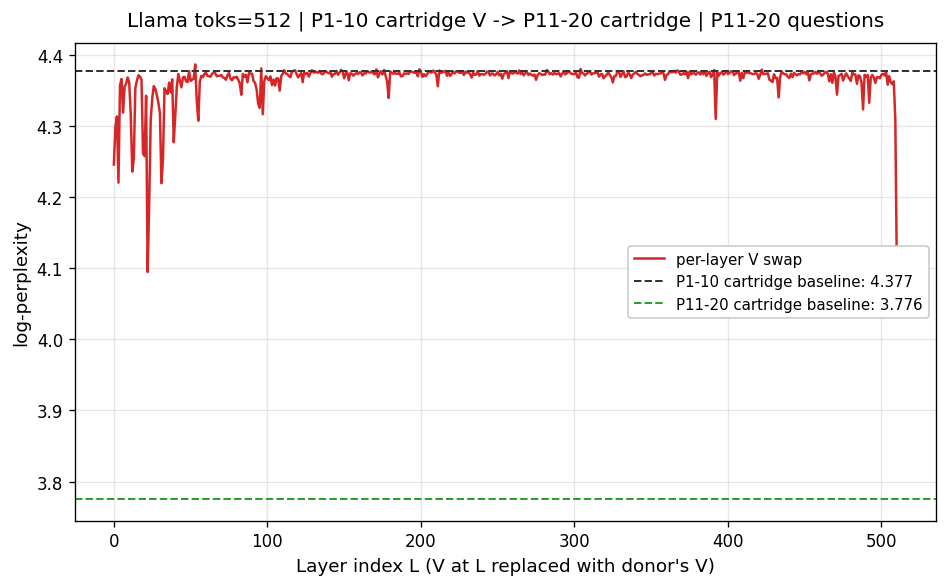

In [22]:
import torch
import matplotlib.pyplot as plt

# Assuming your dictionary is loaded into a variable called `data`
# data = torch.load('your_data_file.pt') # or however you're loading it

# 1. Extract and format the data
# Convert tensors to standard Python floats/numpy arrays for plotting
layer_results = data['log_ppl_per_slot'].cpu().numpy() if torch.is_tensor(data['log_ppl_per_slot']) else data['log_ppl_per_slot']
base_baseline = data['base_nll'].item() if torch.is_tensor(data['base_nll']) else data['base_nll']
donor_baseline = data['donor_nll'].item() if torch.is_tensor(data['donor_nll']) else data['donor_nll']

num_layers = len(layer_results)
layer_indices = range(num_layers)

# 2. Setup the plot
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

# 3. Plot the main per-layer swap line (Red)
ax.plot(layer_indices, layer_results, color='#d62728', linewidth=1.5, label='per-layer V swap')

# 4. Plot the baselines (Black dashed and Green dashed)
ax.axhline(y=base_baseline, color='#333333', linestyle='--', linewidth=1.2, 
           label=f'P1-10 cartridge baseline: {base_baseline:.3f}')

ax.axhline(y=donor_baseline, color='#2ca02c', linestyle='--', linewidth=1.2, 
           label=f'P11-20 cartridge baseline: {donor_baseline:.3f}')

# 5. Styling and Labels
ax.set_title("Llama toks=512 | P1-10 cartridge V -> P11-20 cartridge | P11-20 questions", 
             fontsize=12, pad=10)
ax.set_xlabel("Layer index L (V at L replaced with donor's V)", fontsize=11)
ax.set_ylabel("log-perplexity", fontsize=11)

# Add a light grid just like the reference image
ax.grid(True, linestyle='-', alpha=0.3)

# 6. Legend
# The image has the legend placed roughly center-right
ax.legend(fontsize=9, loc='center right', framealpha=1.0)

# Adjust layout to prevent clipping
plt.tight_layout()

# Show or save the plot
plt.show()
# plt.savefig('v_swap_results.png', bbox_inches='tight')

In [ ]:
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="qtris123/qwen2507_longhealth-p1-10_8192_512_no-cartridge_10-epochs",
    filename="cache_last.pt",
    local_dir="cartridges_pt/qwen3_512_p1"
)
print(f"File downloaded to: {file_path}")

file_path = hf_hub_download(
    repo_id="qtris123/qwen2507_longhealth-p1-10_8192_1024_no-cartridge_10-epochs",
    filename="cache_last.pt",
    local_dir="cartridges_pt/qwen3_1024_p1"
)
print(f"File downloaded to: {file_path}")


file_path = hf_hub_download(
    repo_id="qtris123/qwen2507_longhealth-p1-10_8192_2048_no-cartridge_10-epochs",
    filename="cache_last.pt",
    local_dir="cartridges_pt/qwen3_2048_p1"
)
print(f"File downloaded to: {file_path}")

file_path = hf_hub_download(
    repo_id="qtris123/llama_longhealth-p1-10_8192_512_no-cartridge_10-epochs",
    filename="cache_last.pt",
    local_dir="cartridges_pt/llama_512_p1"
)
print(f"File downloaded to: {file_path}")

file_path = hf_hub_download(
    repo_id="qtris123/llama_longhealth-p1-10_8192_1024_no-cartridge_10-epochs",
    filename="cache_last.pt",
    local_dir="cartridges_pt/llama_1024_p1"
)
print(f"File downloaded to: {file_path}")


file_path = hf_hub_download(
    repo_id="qtris123/llama_longhealth-p1-10_8192_2048_no-cartridge_10-epochs",
    filename="cache_last.pt",
    local_dir="cartridges_pt/llama_2048_p1"
)
print(f"File downloaded to: {file_path}")

File downloaded to: cartridges_pt/qwen3_1024_p1.pt/cache_last.pt


-------------------------------------

In [6]:
import csv
import sys

# Set the limit to the maximum possible for your system
csv.field_size_limit(sys.maxsize)

131072

In [7]:
import csv
import re
from pathlib import Path
from cartridges.structs import Conversation, write_conversations

def convert_longhealth_csv_to_parquet(csv_path: str, parquet_path: str):
    conversations = []
    with open(csv_path, "r", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f)
        for row in reader:
            question_text = row["question"]
            correct = row["correct"]
            metadata = {
                "question_id": row["question_id"],
                "question_type": "longhealth_mc",
                "doc_source": "longhealth",
                "options": [
                    row["answer_a"], row["answer_b"], row["answer_c"],
                    row["answer_d"], row["answer_e"],
                ],
                "answer_location": row.get("answer_location", ""),
            }
            convo = Conversation(
                system_prompt="",
                messages=[
                    Conversation.Message(role="user", content=question_text,
                                         token_ids=None, top_logprobs=None),
                    Conversation.Message(role="assistant", content=correct,
                                         token_ids=None, top_logprobs=None),
                ],
                metadata=metadata,
                type="continual_eval",
            )
            conversations.append(convo)
    write_conversations(conversations, parquet_path)
    print(f"Wrote {len(conversations)} conversations to {parquet_path}")

In [8]:
convert_longhealth_csv_to_parquet("/home/vo43/cartridges/examples/longhealth/data/patient1_10.csv", "/home/vo43/cartridges/experiments_longhealth/longhealth_patient1_10_og.parquet")

Wrote 200 conversations to /home/vo43/cartridges/experiments_longhealth/longhealth_patient1_10_og.parquet


In [9]:
with open("/home/vo43/cartridges/experiments_longhealth/longhealth_patient1_10_og.parquet", "rb") as f:
    df = pd.read_parquet(f)


In [13]:
df.iloc[0]["messages"]

array([{'content': "Please answer the question below about the following patient: ID patient_07, Name: Linda Mayer, Birthday: 1948-12-01 00:00:00, Diagnosis: Breast carcinoma\n\n<question>\nConsidering Mrs. Mayer's medications that were present in 2019 and 2021, which drug's dosing frequency was reduced in the second regimen, likely indicating a clinical improvement?\n</question>\n\n<options>\nAspirin\nSimvastatin\nPantoprazole\nPrednisolone\nAcyclovir\n</options>\nYou should first think step by step. Then give your final answer exactly as it appears in the options. Your output should be in the following format: \n<thinking> {{YOUR_THOUGHT_PROCESS}} </thinking> \n\n<answer>\n{YOUR_ANSWER}\n</answer>", 'role': 'user', 'token_ids': None, 'top_logprobs': None},
       {'content': 'Prednisolone', 'role': 'assistant', 'token_ids': None, 'top_logprobs': None}],
      dtype=object)